# Отбор признаков и сравнение метрик

В ноутбуке рассматривается отбор признаков для CatBoost. Разные наборы сравниваются на одинаковом временном разбиении: первые 80% кампаний используются для обучения, последние 20% для проверки.

Основной критерий выбора: значение метрики на проверочной части. Чем меньше метрика, тем лучше прогноз.


## 1. Импорты и загрузка результатов


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

results = pd.read_csv(ROOT / "feature_selection_results.tsv", sep="\t")
selected_features = [
    line.strip()
    for line in (ROOT / "selected_features.txt").read_text(encoding="utf-8").splitlines()
    if line.strip()
]

display(results)
print(f"Выбрано признаков: {len(selected_features)}")


,feature_set,feature_count,metric
0,without_recent,76,12.35
1,top_10,10,12.39
2,all,100,12.61
3,top_40,40,12.75
4,only_replay,3,12.84
5,top_25,25,12.84
6,top_80,80,12.89
7,without_publisher,72,12.91
8,top_15,15,12.91
9,top_20,20,12.93


Выбрано признаков: 76


## 2. Как проводился отбор

Проверялись три типа наборов:

- `only_*` содержит только одну группу признаков;
- `without_*` содержит все признаки, кроме указанной группы;
- `top_*` содержит несколько самых важных признаков по CatBoost.

Группы признаков:

- `base` - параметры кампании;
- `audience` - характеристики аудитории;
- `publisher` - статистики площадок;
- `recent` - агрегаты истории за последние 31 день;
- `replay` - прогноз replay со сдвигом на месяц.

Для каждого набора CatBoost обучался заново. Метрика считалась на последних 20% кампаний по времени.


## 3. Основные результаты


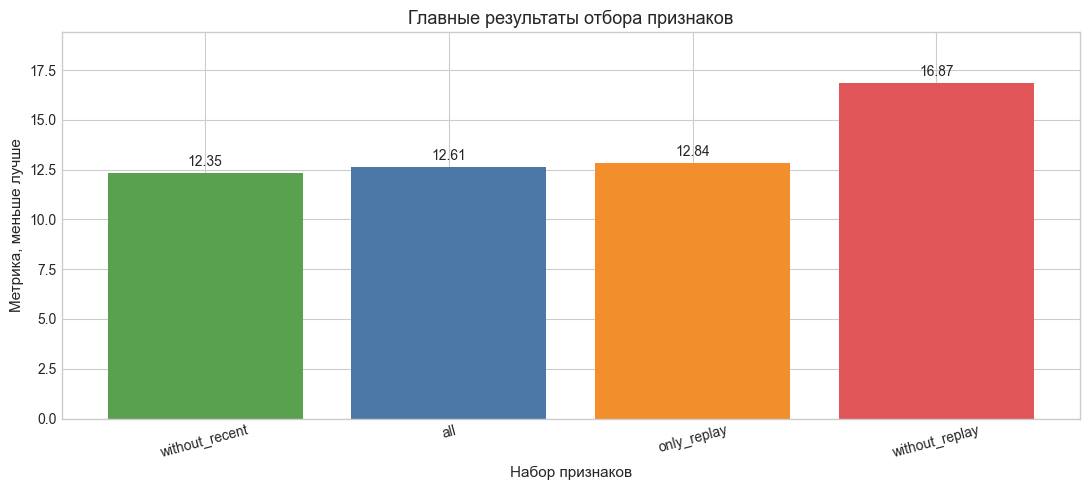

,feature_set,feature_count,metric
0,without_recent,76,12.35
1,all,100,12.61
2,only_replay,3,12.84
3,without_replay,97,16.87


In [2]:
main_sets = ["without_recent", "all", "only_replay", "without_replay"]
comparison = (
    results.set_index("feature_set")
    .loc[main_sets]
    .reset_index()
)

colors = ["#59A14F", "#4C78A8", "#F28E2B", "#E15759"]
bars = plt.bar(comparison["feature_set"], comparison["metric"], color=colors)
plt.bar_label(bars, fmt="%.2f", padding=3)
plt.title("Главные результаты отбора признаков")
plt.xlabel("Набор признаков")
plt.ylabel("Метрика, меньше лучше")
plt.xticks(rotation=15)
plt.ylim(0, comparison["metric"].max() * 1.15)
plt.tight_layout()
plt.show()

display(comparison)


Лучший результат получен без признаков `recent_31d_*`: метрика снизилась с 12.61 до 12.35. Только три replay-признака дают 12.84, а удаление replay ухудшает результат до 16.87.

Это означает, что replay содержит основную информацию для прогноза. Остальные выбранные признаки немного уточняют результат, а агрегаты последних 31 дней в текущем виде добавляют шум.


## 4. Сравнение всех наборов


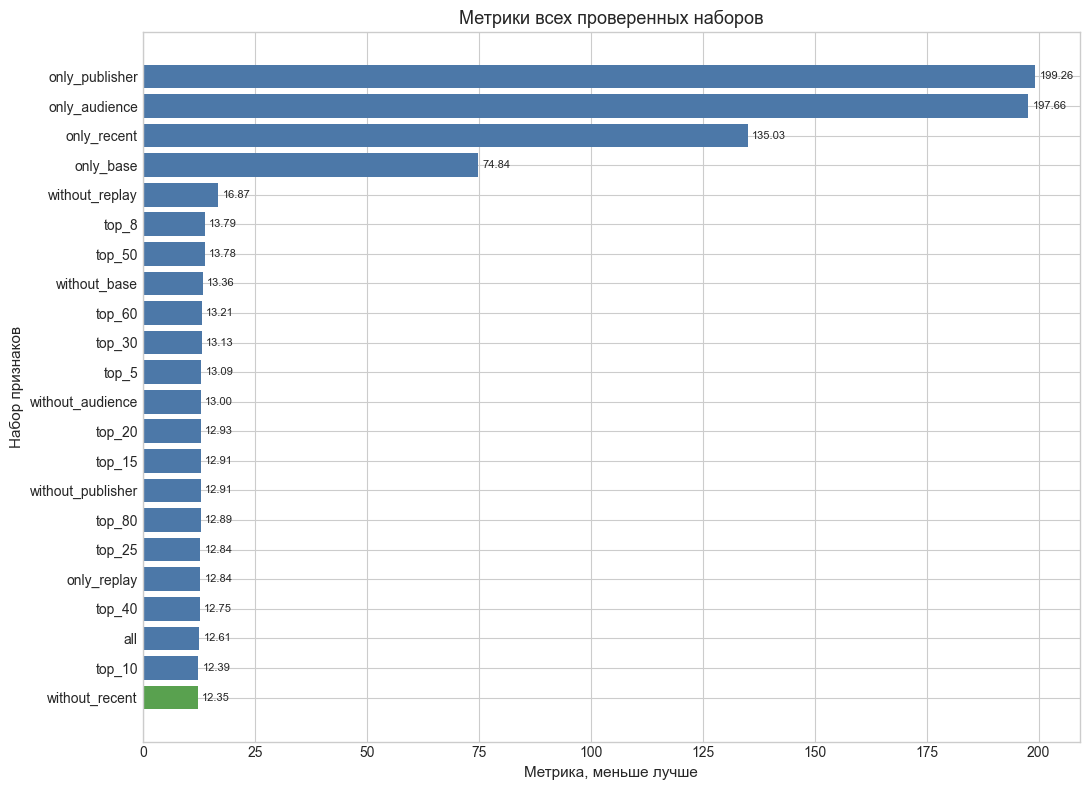

In [3]:
ordered = results.sort_values("metric", ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))
colors = [
    "#59A14F" if name == "without_recent" else "#4C78A8"
    for name in ordered["feature_set"]
]
bars = ax.barh(ordered["feature_set"], ordered["metric"], color=colors)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
ax.set(
    title="Метрики всех проверенных наборов",
    xlabel="Метрика, меньше лучше",
    ylabel="Набор признаков",
)
plt.tight_layout()
plt.show()


## 5. Число признаков и качество


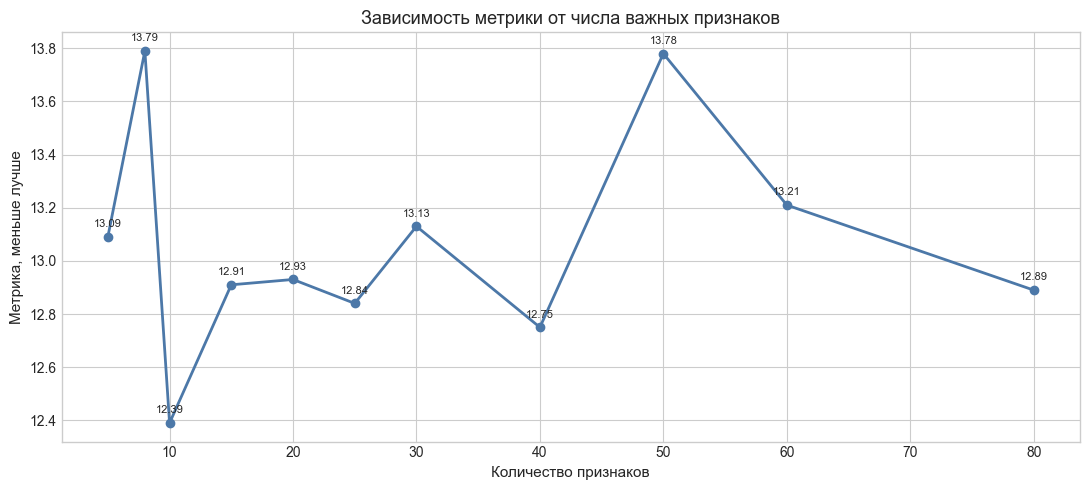

In [4]:
top_sets = results[results["feature_set"].str.startswith("top_")].sort_values("feature_count")

plt.plot(
    top_sets["feature_count"],
    top_sets["metric"],
    marker="o",
    linewidth=2,
    color="#4C78A8",
)
for row in top_sets.itertuples():
    plt.annotate(
        f"{row.metric:.2f}",
        (row.feature_count, row.metric),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )
plt.title("Зависимость метрики от числа важных признаков")
plt.xlabel("Количество признаков")
plt.ylabel("Метрика, меньше лучше")
plt.tight_layout()
plt.show()


## 6. Итоговый набор признаков


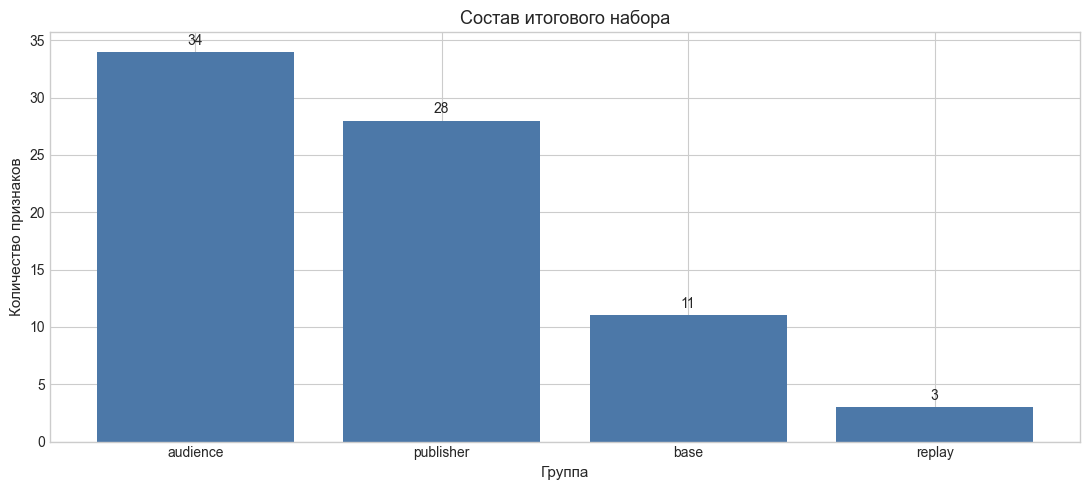

,feature,group
0,cpm,base
1,log_cpm,base
2,hour_start,base
3,hour_end,base
4,window_length,base
...,...,...
71,cpm_to_pub_p90,base
72,cpm_to_pub_p95,base
73,shift_replay_at_least_one,replay
74,shift_replay_at_least_two,replay


In [5]:
def feature_group(feature):
    if feature.startswith("shift_replay_"):
        return "replay"
    if feature.startswith("audience_"):
        return "audience"
    if feature.startswith("publisher_"):
        return "publisher"
    if feature.startswith("recent_"):
        return "recent"
    return "base"


selected_table = pd.DataFrame({"feature": selected_features})
selected_table["group"] = selected_table["feature"].map(feature_group)
group_counts = selected_table["group"].value_counts()

bars = plt.bar(group_counts.index, group_counts.values, color="#4C78A8")
plt.bar_label(bars, padding=3)
plt.title("Состав итогового набора")
plt.xlabel("Группа")
plt.ylabel("Количество признаков")
plt.tight_layout()
plt.show()

display(selected_table)


## 7. Отбор признаков для калибровки replay

В этом эксперименте replay остается основным прогнозом, а ML предсказывает только поправку к нему. Поэтому три replay-признака сохраняются во всех наборах. Отбираются дополнительные признаки, которые помогают исправлять ошибки replay.


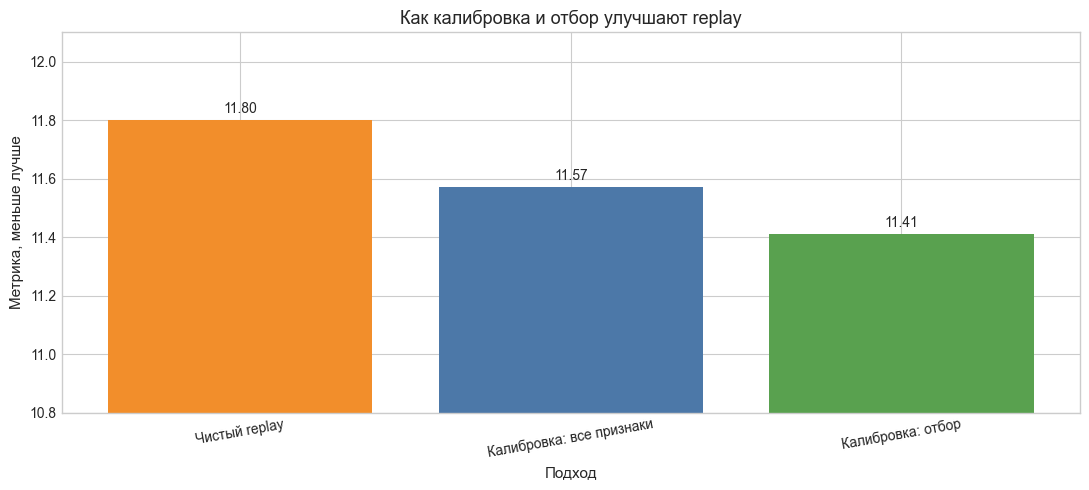

,variant,metric
0,Чистый replay,11.80
1,Калибровка: все признаки,11.57
2,Калибровка: отбор,11.41


In [6]:
calibration_results = pd.read_csv(
    ROOT / "calibration_feature_selection_results.tsv",
    sep="\t",
)
calibration_features = [
    line.strip()
    for line in (ROOT / "selected_calibration_features.txt")
    .read_text(encoding="utf-8")
    .splitlines()
    if line.strip()
]

main_calibration = pd.DataFrame({
    "variant": ["Чистый replay", "Калибровка: все признаки", "Калибровка: отбор"],
    "metric": [
        11.80,
        calibration_results.loc[
            calibration_results["feature_set"] == "all", "metric"
        ].iloc[0],
        calibration_results.iloc[0]["metric"],
    ],
})

colors = ["#F28E2B", "#4C78A8", "#59A14F"]
bars = plt.bar(main_calibration["variant"], main_calibration["metric"], color=colors)
plt.bar_label(bars, fmt="%.2f", padding=3)
plt.title("Как калибровка и отбор улучшают replay")
plt.xlabel("Подход")
plt.ylabel("Метрика, меньше лучше")
plt.ylim(10.8, 12.1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

display(main_calibration)


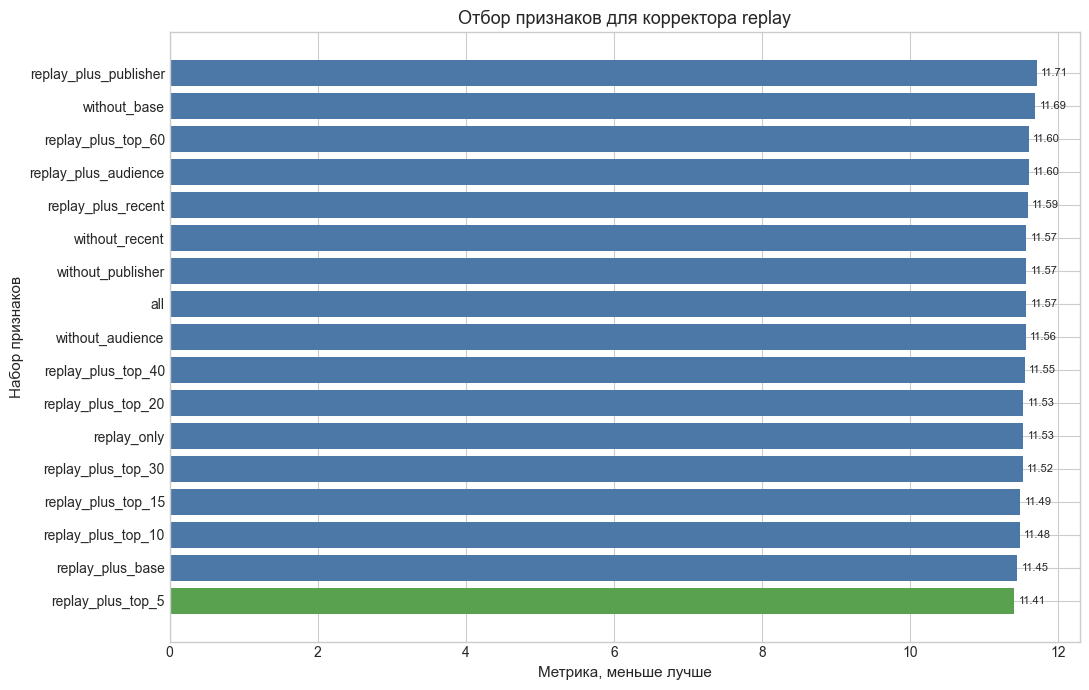

,feature_set,feature_count,model,shrink,metric
0,replay_plus_top_5,8,ridge_50,0.90,11.41
1,replay_plus_base,14,ridge_50,0.80,11.45
2,replay_plus_top_10,13,ridge_50,0.75,11.48
3,replay_plus_top_15,18,catboost_conservative,0.60,11.49
4,replay_plus_top_30,33,catboost_conservative,0.70,11.52
5,replay_only,3,ridge_50,0.95,11.53
6,replay_plus_top_20,23,ridge_50,0.60,11.53
7,replay_plus_top_40,43,elastic_net,0.60,11.55
8,without_audience,66,elastic_net,0.55,11.56
9,all,100,catboost_conservative,0.65,11.57


In [7]:
ordered_calibration = calibration_results.sort_values("metric", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
colors = [
    "#59A14F" if name == "replay_plus_top_5" else "#4C78A8"
    for name in ordered_calibration["feature_set"]
]
bars = ax.barh(
    ordered_calibration["feature_set"],
    ordered_calibration["metric"],
    color=colors,
)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
ax.set(
    title="Отбор признаков для корректора replay",
    xlabel="Метрика, меньше лучше",
    ylabel="Набор признаков",
)
plt.tight_layout()
plt.show()

display(calibration_results)


Лучший набор `replay_plus_top_5` содержит три replay-прогноза и пять дополнительных признаков. Для него лучший результат показывает Ridge со `shrink = 0.90`: метрика 11.41. Использование всех 100 признаков дает 11.57, поэтому компактный набор меньше переобучается и лучше исправляет replay.


In [8]:
pd.DataFrame({"selected_calibration_feature": calibration_features})


,selected_calibration_feature
0,shift_replay_at_least_one
1,shift_replay_at_least_two
2,shift_replay_at_least_three
3,hour_end
4,window_length
5,log_window_length
6,recent_31d_intersection_win_rate
7,publisher_pub_hour_std_median


## 8. Сравнение моделей

Все модели обучаются на одинаковых 76 выбранных признаках и проверяются на последних 20% кампаний по времени. Поэтому значения метрики можно сравнивать напрямую.


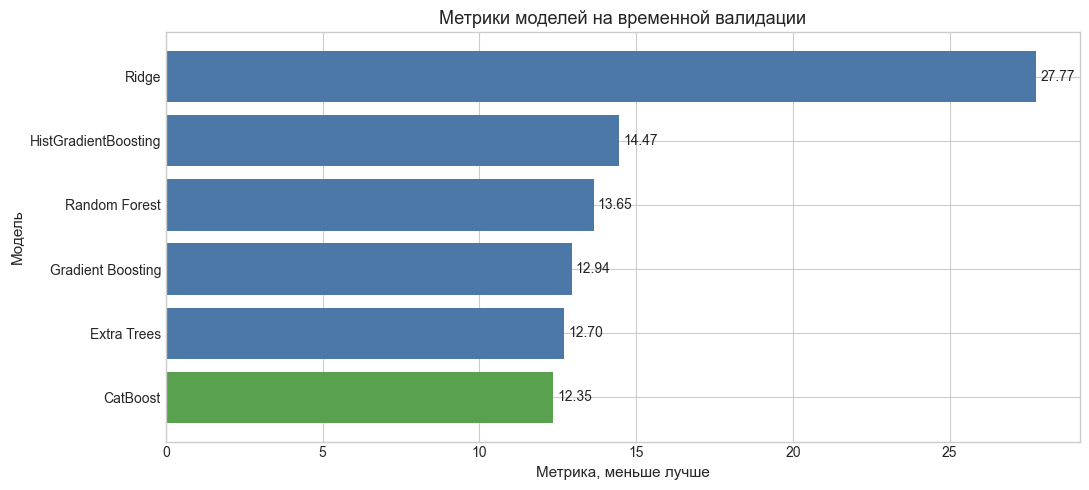

,model,metric
0,catboost,12.35
1,extra_trees,12.70
2,gradient_boosting,12.94
3,random_forest,13.65
4,hist_gradient_boosting,14.47
5,ridge,27.77


In [9]:
model_metrics = pd.read_csv(ROOT / "model_metrics.tsv", sep="\t")
model_metrics = model_metrics.sort_values("metric", ascending=True)

labels = {
    "catboost": "CatBoost",
    "extra_trees": "Extra Trees",
    "gradient_boosting": "Gradient Boosting",
    "random_forest": "Random Forest",
    "hist_gradient_boosting": "HistGradientBoosting",
    "ridge": "Ridge",
}
plot_data = model_metrics.copy()
plot_data["model_name"] = plot_data["model"].map(labels)

colors = [
    "#59A14F" if model == "catboost" else "#4C78A8"
    for model in plot_data["model"]
]
bars = plt.barh(plot_data["model_name"], plot_data["metric"], color=colors)
plt.bar_label(bars, fmt="%.2f", padding=3)
plt.title("Метрики моделей на временной валидации")
plt.xlabel("Метрика, меньше лучше")
plt.ylabel("Модель")
plt.tight_layout()
plt.show()

display(model_metrics[["model", "metric"]].reset_index(drop=True))


Лучший результат показывает CatBoost с метрикой 12.35. Близкие результаты получены у Extra Trees и Gradient Boosting. Линейная модель Ridge заметно уступает моделям на деревьях, что указывает на нелинейные зависимости между признаками и целевыми значениями.


## 9. Вывод

Для обычного CatBoost выбран набор из 76 признаков без `recent_31d_*`. Его метрика на временной валидации равна **12.35**.

Лучший итоговый подход использует replay и ML-корректор. После отдельного отбора корректору оставлены 8 признаков: три replay-прогноза и пять признаков для поправки. Ridge со `shrink = 0.90` улучшает чистый replay с **11.80** до **11.41**.

Отбор относится к текущему временному разбиению. При изменении модели или схемы валидации набор признаков необходимо проверить заново.
